<a href="https://colab.research.google.com/github/DinRazar/data-data/blob/main/%D0%A0%D0%B0%D0%B1%D0%BE%D1%82_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №1. Разведочный анализ, предобработка данных и построение модели классификации *(на примере датасета Bank Marketing)***

---

## **Введение**


**Цель работы:** Обучить модель машинного обучения для предсказания, откроет ли клиент банка срочный вклад по результатам маркетинговой кампании (целевая переменная `y`: "yes" — откроет, "no" — не откроет).


**Датасет:** [Bank Marketing Dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing) — данные о маркетинговых кампаниях португальского банка.



**Что вы научитесь делать:**
- Загружать и исследовать данные
- Выявлять проблемы через разведочный анализ (EDA)
- Анализировать и обрабатывать пропущенные значения
- Формулировать и проверять гипотезы
- Создавать новые признаки (Feature Engineering)
- Сравнивать стратегии и выбирать лучшую модель

---

## **Часть 1. Настройка окружения**

> 📚 **Подсказка:** Аналогичная настройка рассматривалась в [**Занятии 1, Часть 1** и **Занятии 2, Часть 1**](https://colab.research.google.com/drive/1Cnp7hPUUu5dorlhPPHUeztnnoq5Z2j4W?usp=sharing#scrollTo=5f49d9aa).

In [1]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Настройки отображения
sns.set_style("whitegrid")
pd.set_option('display.max_columns', 20)

---

## **Часть 2. Загрузка и первичный осмотр данных**

> 📚 **Подсказка:** Методы первичного осмотра (`head()`, `info()`, `describe()`, `shape`) подробно разобраны в [**Занятии 1, Часть 3.2**](https://colab.research.google.com/drive/1Cnp7hPUUu5dorlhPPHUeztnnoq5Z2j4W?usp=sharing#scrollTo=9ef7543b) и [**Занятии 2, Часть 2.1**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=43b439e3).

### **Задание 2.1. Загрузите датасет**

In [2]:
# Загрузка датасета Bank Marketing
url = "https://raw.githubusercontent.com/rishabhathiya/Bank-Marketing/refs/heads/main/bank.csv"
bank = pd.read_csv(url, sep=';')

# ВАЖНО: В этом датасете пропуски записаны как "unknown"
# Заменяем их на NaN, чтобы isna() корректно их определял
bank = bank.replace('unknown', np.nan)

bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,NaN,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,NaN,3,jun,199,4,-1,0,NaN,no
4,59,blue-collar,married,secondary,no,0,yes,no,NaN,5,may,226,1,-1,0,NaN,no


### **Задание 2.2. Изучите структуру данных**

**1. Выведите размерность датасета:**

In [3]:
bank.shape

(4521, 17)

**2. Отобразите первые 10 строк датасета**

In [4]:
bank.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,NaN,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,NaN,3,jun,199,4,-1,0,NaN,no
4,59,blue-collar,married,secondary,no,0,yes,no,NaN,5,may,226,1,-1,0,NaN,no
5,35,management,single,tertiary,no,747,no,no,cellular,23,feb,141,2,176,3,failure,no
6,36,self-employed,married,tertiary,no,307,yes,no,cellular,14,may,341,1,330,2,other,no
7,39,technician,married,secondary,no,147,yes,no,cellular,6,may,151,2,-1,0,NaN,no
8,41,entrepreneur,married,tertiary,no,221,yes,no,NaN,14,may,57,2,-1,0,NaN,no
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no


**3. Выведите информацию о типах данных и пропусках**

In [5]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4483 non-null   object
 2   marital    4521 non-null   object
 3   education  4334 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    3197 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   816 non-null    object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


**4. Выведите статистику числовых признаков**


In [6]:
bank.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


**5. Выведите названия всех столбцов в виде списка строк**

In [7]:
list(bank.columns)

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

### **Задание 2.3. Ответьте на вопросы**

---

> 📝 **Как отвечать на текстовые вопросы?** Дважды кликните на ячейку → впишите ответ → нажмите `Shift+Enter`

---


**Вопрос 1:** Сколько записей (клиентов) в датасете?

**Ответ:** 4521

**Вопрос 2:** Сколько признаков (столбцов)?


**Ответ:** 17

**Вопрос 3:** Какая переменная является целевой (что предсказываем)?


**Ответ:** y — открыл ли клиент срочный вклад (yes/no). Позже создаём числовую версию target


**Вопрос 4:** Какие типы данных преобладают — числовые или категориальные?

**Ответ:** Преобладают категориальные: 10 категориальных и 7 числовых.

---

### **Описание столбцов датасета Bank Marketing**

| Столбец | Описание | Тип |
|---------|----------|-----|
| `age` | Возраст клиента | Числовой |
| `job` | Тип занятости | Категориальный |
| `marital` | Семейное положение | Категориальный |
| `education` | Уровень образования | Категориальный |
| `default` | Есть ли дефолт по кредиту | Категориальный |
| `balance` | Баланс на счёте (евро) | Числовой |
| `housing` | Есть ли ипотека | Категориальный |
| `loan` | Есть ли личный кредит | Категориальный |
| `contact` | Тип связи | Категориальный |
| `day` | День последнего контакта | Числовой |
| `month` | Месяц последнего контакта | Категориальный |
| `duration` | Длительность последнего звонка (сек) | Числовой |
| `campaign` | Кол-во контактов в этой кампании | Числовой |
| `pdays` | Дней с последнего контакта (-1 = не было) | Числовой |
| `previous` | Кол-во контактов до этой кампании | Числовой |
| `poutcome` | Результат прошлой кампании | Категориальный |
| `y` | **Целевая переменная:** открыл ли вклад | Категориальный |

---

## **Часть 3. Разведочный анализ данных (EDA)**

> 📚 **Подсказка:** Цель EDA — выявить проблемы в данных и найти закономерности (паттерны). Методология описана в [**Занятии 2, Часть 2**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=29f19e7a).

### **3.1. Анализ целевой переменной (баланс классов)**

> 📚 **Подсказка:** Анализ баланса классов рассмотрен в [**Занятии 2, Часть 2.3**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=15c684d7).

In [8]:
# Создаём числовую версию целевой переменной в столбце target
bank['target'] = (bank['y'] == 'yes').astype(int)

bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,target
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,NaN,no,0
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no,0
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no,0
3,30,management,married,tertiary,no,1476,yes,yes,NaN,3,jun,199,4,-1,0,NaN,no,0
4,59,blue-collar,married,secondary,no,0,yes,no,NaN,5,may,226,1,-1,0,NaN,no,0


**Подсчитайте распределение целевой переменной 'y'**

y
no     4000
yes     521
Name: count, dtype: int64


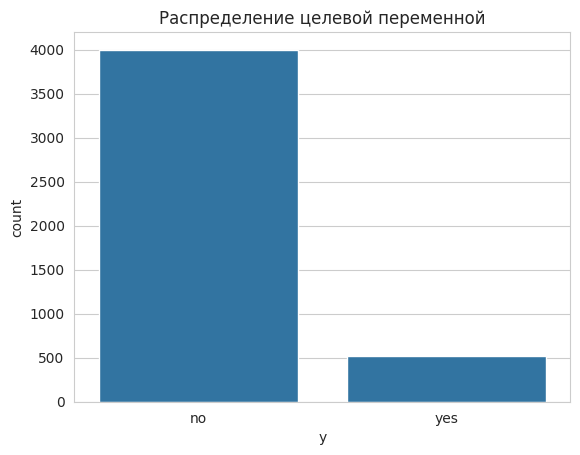

Доля открывших вклад: 11.52%


In [9]:
bank['target'] = (bank['y'] == 'yes').astype(int)

# Распределение
print(bank['y'].value_counts())

# Визуализация
sns.countplot(data=bank, x='y')
plt.title('Распределение целевой переменной')
plt.show()

# Процент открывших вклад
print(f"Доля открывших вклад: {bank['target'].mean() * 100:.2f}%")

**Вопрос:** сколько клиентов открыли депозит (yes)? сколько не открыли (no)?



**Ответ:** no — 4000, yes — 521.

---

**Вопрос:** Сбалансированы ли классы? Какой класс преобладает?

**Ответ:** Классы несбалансированы. Преобладает класс no (≈88.5%). Доля yes ≈ 11.5%

---

### **3.2. Анализ пропущенных значений**

> 📚 **Подсказка:** Проверка пропусков с помощью `isna().sum()` показана в [**Занятии 1, Часть 3.6**](https://colab.research.google.com/drive/1Cnp7hPUUu5dorlhPPHUeztnnoq5Z2j4W?usp=sharing#scrollTo=1f244634) и [**Занятии 2, Часть 2.2**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=e96e5f15).

**Проверьте наличие пропущенных значений в датасете с помощью `isna().sum()`**

In [10]:
# Количество пропусков
bank.isna().sum()

,0
age,0
job,38
marital,0
education,187
default,0
balance,0
housing,0
loan,0
contact,1324
day,0


**Вычислите процент пропущенных значений в каждом столбце датасета**

In [11]:
# Процент пропусков
missing_percent = bank.isna().mean() * 100
missing_percent[missing_percent > 0].sort_values(ascending=False)

,0
poutcome,81.950896
contact,29.285556
education,4.136253
job,0.840522


**Постройте столбчатую диаграмму (`barplot`) для визуализации процента пропусков**

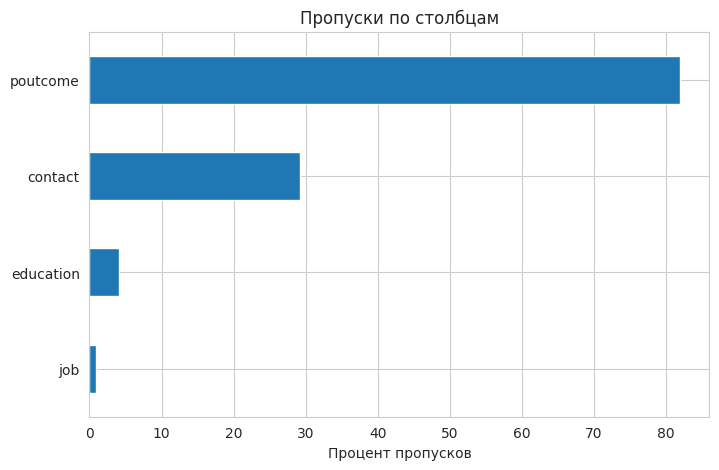

In [12]:
# Визуализация
missing_percent[missing_percent > 0].sort_values().plot(kind='barh', figsize=(8, 5))
plt.xlabel('Процент пропусков')
plt.title('Пропуски по столбцам')
plt.show()

**Вопрос:** В каких столбцах больше всего пропусков? Какой процент данных потеряем, если удалим все строки с пропусками?





**Ответ:** Больше всего пропусков в poutcome (≈82%), затем contact (≈29%), default (≈17%), education (≈4%), job (≈1%). Если удалить все строки с пропусками, потеряем более 80% данных — это неприемлемо.



---

### **3.3. Анализ числовых признаков**

> 📚 **Подсказка:** Построение гистограмм с разбивкой по целевой переменной (`hue`) показано в [**Занятии 2, Часть 2.4**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=ea28aa58).



**Обязательно постройте гистограммы для следующих признаков:**
- `age` — возраст
- `balance` — баланс на счёте  
- `duration` — длительность звонка

**Постройте гистограммы для числовых признаков с разбивкой по целевой переменной**

> Используйте `sns.histplot()` с параметром `hue='target'`

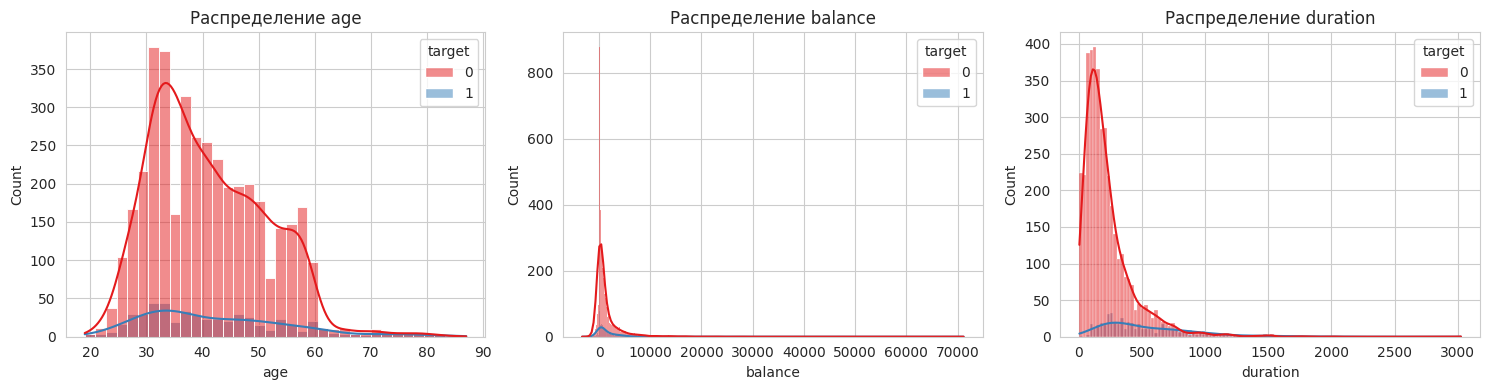

In [13]:
numeric_features = ['age', 'balance', 'duration']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(numeric_features):
    sns.histplot(data=bank, x=col, hue='target', kde=True, ax=axes[i], palette='Set1')
    axes[i].set_title(f'Распределение {col}')

plt.tight_layout()
plt.show()

*(При желании, можете не использовать мои шаблоны, а написать код для построения графиков с нуля и самостоятельно)*

**Вопрос:** Какие наблюдения вы можете сделать? Какие признаки различаются для клиентов, открывших и не открывших вклад?



**Ответ:** duration сильно различается у классов: у клиентов, открывших вклад, звонки в среднем длиннее. age и balance различаются слабее, но у yes баланс немного выше.



---

### **Задание 3.4. Анализ категориальных признаков**

> 📚 **Подсказка:** Построение столбчатой диаграммы (`barplot`) для анализа связи категориальных признаков с целевой переменной показано в [**Занятии 2, Часть 2.5**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=ea6a781f).



**Постройте графики для анализа доли открывших депозит по категориальным признакам ('job', 'marital', 'education', 'contact'):**

/tmp/ipykernel_523/1651336267.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bank, x=col, y='target', ax=axes[i], palette='viridis')
/tmp/ipykernel_523/1651336267.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bank, x=col, y='target', ax=axes[i], palette='viridis')
/tmp/ipykernel_523/1651336267.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bank, x=col, y='target', ax=axes[i], palette='viridis')
/tmp/ipykernel_523/1651336267.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will 

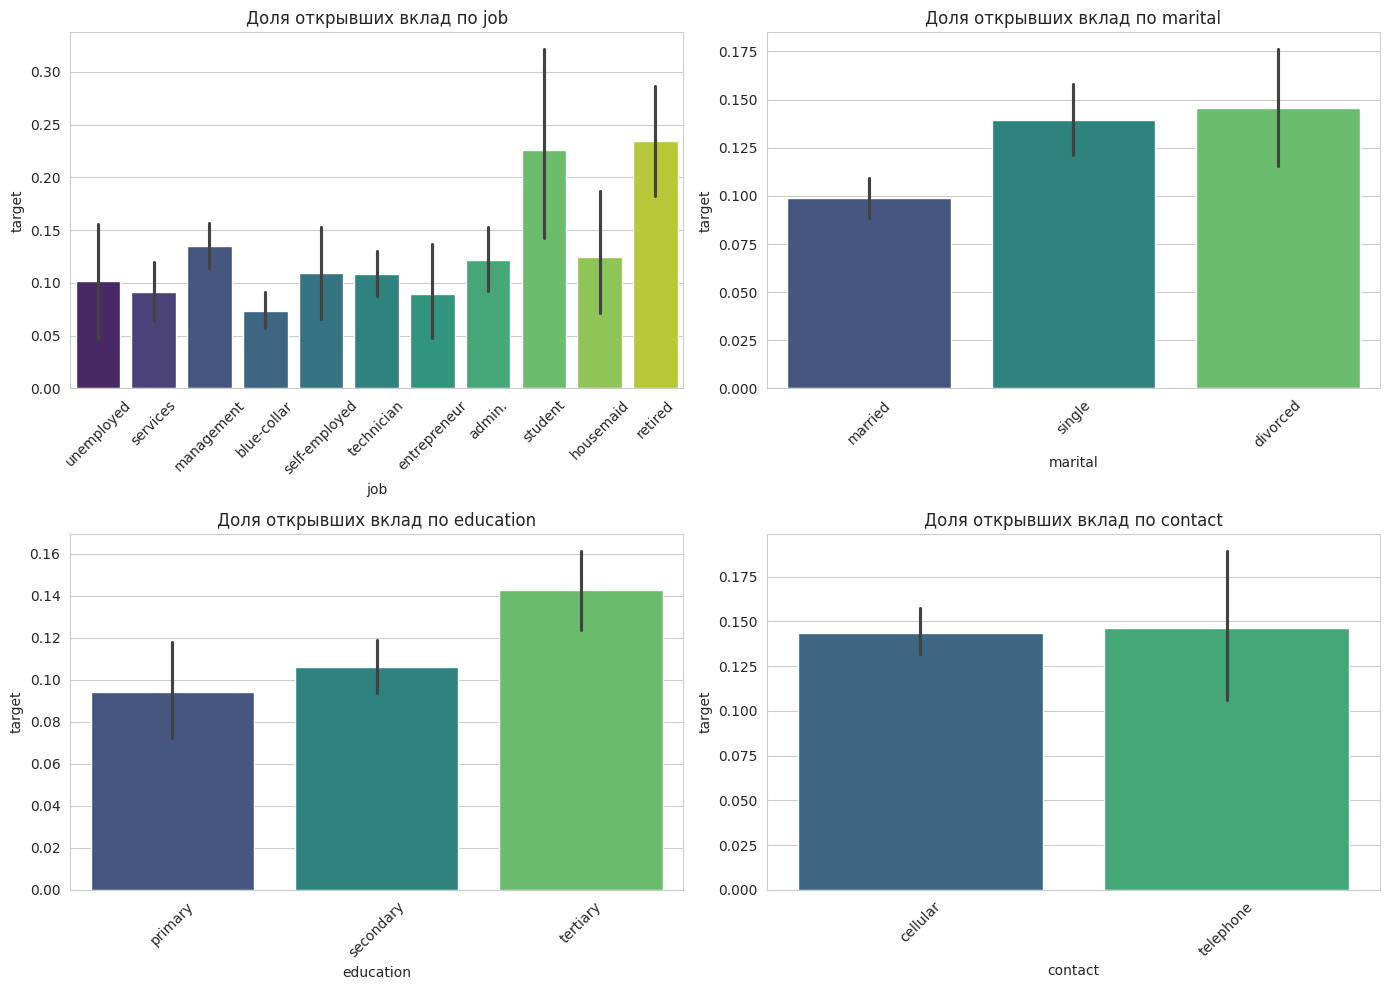

In [14]:
cat_features = ['job', 'marital', 'education', 'contact']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.barplot(data=bank, x=col, y='target', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Доля открывших вклад по {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---

**Ответьте на вопросы:**


**Вопрос:** Люди каких профессий чаще открывают депозит?



**Ответ:** Чаще — student, retired, management.


**Вопрос:** Влияет ли семейное положение на вероятность открытия депозита?


**Ответ:** Влияние слабое. Немного чаще открывают single.




**Вопрос:** Какой тип связи (contact) наиболее эффективен?



**Ответ:** cellular — самый эффективный.


**Вопрос:** Какие в общем категории клиентов чаще открывают вклад (примерный портрет по всем категориальным признакам в совокупности)?



**Ответ:** Студент или пенсионер, с высшим образованием, одинокий, контакт по cellular, без кредитов, с положительным балансом.





---

### **Задание 3.5. Анализ связей между признаками (Boxplot)**

> 📚 **Подсказка:** Использование boxplot для анализа распределений показано в [**Занятии 2, Часть 2.6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=592b07cc).

**Постройте `boxplot` для анализа баланса по уровню образования**

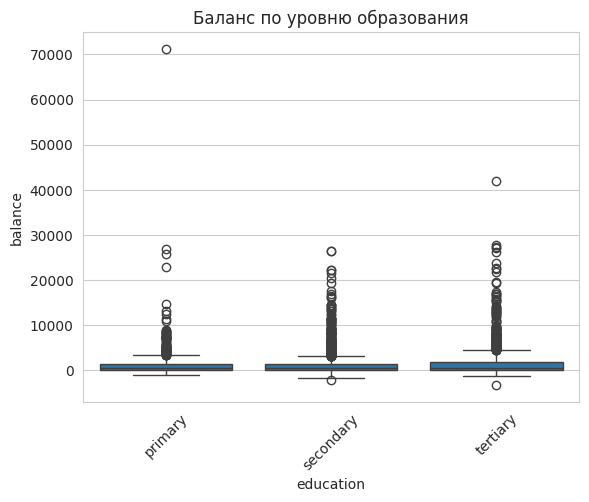

In [15]:
sns.boxplot(data=bank, x='education', y='balance')
plt.xticks(rotation=45)
plt.title('Баланс по уровню образования')
plt.show()

**Вопрос:** Различается ли баланс у клиентов с разным образованием?



**Ответ:** Да, у клиентов с tertiary медианный баланс выше, чем у primary и secondary.



---

### **Задание 3.6. Группировка данных**

> 📚 **Подсказка:** Метод `groupby()` подробно разобран в [**Занятии 1, Часть 3.7**](https://colab.research.google.com/drive/1Cnp7hPUUu5dorlhPPHUeztnnoq5Z2j4W?usp=sharing#scrollTo=baa512e4).

**Вычислите средний баланс и долю открывших депозит по типу работы**

In [16]:
bank.groupby('job').agg(
    avg_balance=('balance', 'mean'),
    target_rate=('target', 'mean')
).sort_values('target_rate', ascending=False)

,avg_balance,target_rate
job,,
retired,2319.191304,0.234783
student,1543.821429,0.226190
management,1766.928793,0.135191
housemaid,2083.803571,0.125000
admin.,1226.736402,0.121339
self-employed,1392.409836,0.109290
technician,1330.996094,0.108073
unemployed,1089.421875,0.101562
services,1103.956835,0.091127


**Вычислите долю открывших депозит по уровню образования**

In [17]:
bank.groupby('education')['target'].mean().sort_values(ascending=False)

,target
education,
tertiary,0.142963
secondary,0.106245
primary,0.094395


---

## **Часть 4. Формулировка гипотез**

> 📚 **Подсказка:** Формулировка гипотез на основе EDA описана в [**Занятии 2, Часть 3**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=329f49e7).



На основе проведённого EDA сформулируйте **минимум 3 гипотезы** о том, какие признаки и преобразования могут улучшить модель.

### **Ваши гипотезы:**

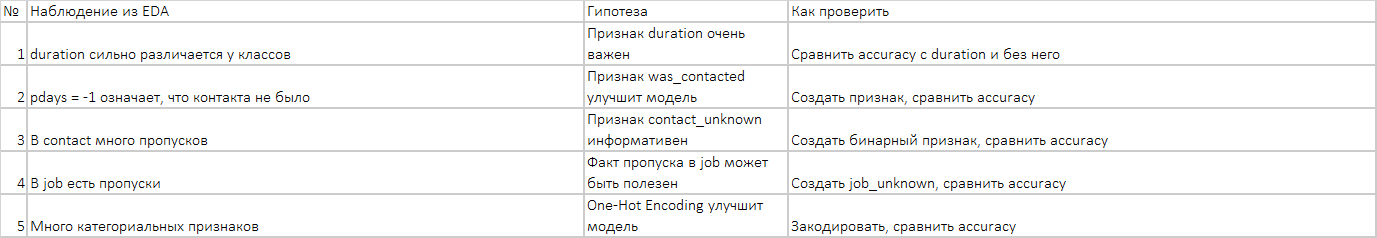

**Примеры формулировок (для ориентира):**

| Наблюдение | Гипотеза | Как проверить |
|------------|----------|---------------|
| `duration` сильно различается у классов | Признак важен для предсказания | Сравнить accuracy с `duration` и без него |
| `pdays` = -1 означает "не контактировали" | Создать бинарный признак `was_contacted` | Создать признак, сравнить accuracy |
| `balance` имеет отрицательные значения | Создать признак `has_positive_balance` | Создать признак, сравнить accuracy |
| В `job` есть пропуски | Факт пропуска может быть информативен | Создать `job_unknown`, сравнить accuracy |
| В `education` есть пропуски | Заполнение модой лучше удаления строк | Сравнить стратегии обработки пропусков |
| В `contact` много пропусков | Признак `contact_unknown` улучшит модель | Добавить признак, сравнить accuracy |
| Много категориальных признаков | One-Hot Encoding улучшит модель | `pd.get_dummies()`, сравнить accuracy |

**Примеры кода для проверки гипотез: (пригодится в следующем пункте)**

> 📚 **Подсказка:** Методология проверки гипотез через эксперименты подробно разобрана в [**Занятии 2, Часть 6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=28a74583).



**Проверка гипотезы: важность признака `duration`**

```python
# С duration
cols_with_duration = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
accuracy_with = evaluate_model(df[cols_with_duration], df['target'])

# Без duration
cols_without_duration = ['age', 'balance', 'campaign', 'pdays', 'previous']
accuracy_without = evaluate_model(df[cols_without_duration], df['target'])

print(f"С duration:    {accuracy_with:.4f}")
print(f"Без duration:  {accuracy_without:.4f}")
print(f"Разница:       {accuracy_with - accuracy_without:+.4f}")
```



**Проверка гипотезы: информативность пропуска в `job`**

```python
# Проверяем: различается ли доля положительного класса?
print("Доля открывших вклад по группам:")
print(bank.groupby(bank['job'].isna())['target'].mean())

# Если доли сильно различаются → признак потенциально полезен
```



---

## **Часть 5. Базовая (baseline) модель**

> 📚 **Подсказка:** Создание baseline модели с использованием только числовых признаков описано в [**Занятии 2, Часть 4**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=47225a7d).

**Baseline** — простейшая работающая модель, с которой мы будем сравнивать все улучшения.

### **5.1. Вспомогательная функция**

> 📚 **Подсказка:** Функция `evaluate_model()` создана в [**Занятии 2, после Части 4.6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=maxKagcsxhv8).

In [18]:
def evaluate_model(X, y):
    """
    Обучает логистическую регрессию и возвращает accuracy.
    """
    # 1. Разделение данных (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # 2. Масштабирование (ВАЖНО: fit только на train!)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 3. Обучение модели
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train_scaled, y_train)

    # 4. Предсказание и оценка
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)

    return accuracy

### **5.2. Подготовка данных для baseline**

In [19]:
# Выбираем только числовые признаки для baseline
numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Подготовьте X и y
X_baseline = bank[numeric_cols]
y_baseline = bank['target']

print(f"Размер X: {X_baseline.shape}")
print(f"Размер y: {y_baseline.shape}")

Размер X: (4521, 7)
Размер y: (4521,)


### **5.3. Обучите базовую (baseline) модель**

<details>
<summary><b>Пример кода:</b></summary>



```python
# Обучите baseline и сохраните результат
accuracy_baseline = evaluate_model(X_baseline, y_baseline)

# Словарь для хранения результатов экспериментов
results = {}
results['baseline'] = {'accuracy': accuracy_baseline, 'n_features': len(numeric_cols)}

print("=" * 50)
print("BASELINE МОДЕЛЬ")
print("=" * 50)
print(f"Признаки: {numeric_cols}")
print(f"Количество признаков: {len(numeric_cols)}")
print(f"Accuracy: {accuracy_baseline:.4f} ({accuracy_baseline:.1%})")
print("=" * 50)

```



In [20]:
results = {}

accuracy_baseline = evaluate_model(X_baseline, y_baseline)
results['baseline'] = accuracy_baseline

print("=" * 50)
print("BASELINE МОДЕЛЬ")
print("=" * 50)
print(f"Признаки: {numeric_cols}")
print(f"Количество признаков: {len(numeric_cols)}")
print(f"Accuracy: {accuracy_baseline:.4f} ({accuracy_baseline:.1%})")
print("=" * 50)

BASELINE МОДЕЛЬ
Признаки: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Количество признаков: 7
Accuracy: 0.8862 (88.6%)


---

## **Часть 6. Стратегии обработки пропусков**

> 📚 **Подсказка:** Стратегии заполнения пропусков (удаление, заполнение модой/медианой, создание признаков) подробно разобраны в [**Занятии 2, Часть 5**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=89cec4d9).

### **6.1. Стратегия A: Удаление строк с пропусками**

In [21]:
# Посмотрим, сколько данных потеряем
df_dropped = bank.dropna()

print(f"Было строк: {len(bank)}")
print(f"Стало строк: {len(df_dropped)}")
print(f"Потеряно: {len(bank) - len(df_dropped)} ({(len(bank) - len(df_dropped)) / len(bank) * 100:.1f}%)")

Было строк: 4521
Стало строк: 764
Потеряно: 3757 (83.1%)


**Вопрос:** Приемлемо ли терять столько данных?



**Ответ:** Нет, потеряем более 80% данных из-за poutcome. Это неприемлемо.



---

### **6.2. Стратегия B: Заполнение модой**

> 📚 **Подсказка:** Заполнение пропусков модой через `fillna()` рассматривалось в [**Занятии 2, Часть 5, Стратегия B**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=8e470458).

**Заполните категориальные пропуски модой (самым частым значением)**

In [22]:
df_filled = bank.copy()

cat_cols_with_na = ['job', 'education', 'contact', 'poutcome', 'default']

for col in cat_cols_with_na:
    if col in df_filled.columns and df_filled[col].isna().sum() > 0:
        mode_value = df_filled[col].mode()[0]
        df_filled[col] = df_filled[col].fillna(mode_value)

print(f"Пропусков после заполнения: {df_filled.isna().sum().sum()}")

Пропусков после заполнения: 0


### **6.3. Стратегия C: Создание признаков из пропусков**

> 📚 **Подсказка:** Создание бинарных признаков из пропусков (например, `has_cabin` в Titanic) рассматривалось в [**Занятии 2, Часть 6, Эксперимент 2, Тест D**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=df9d9180).
>
> **Идея:** Сам факт того, что значение неизвестно, может быть информативен! Например: если клиент не указал профессию — это может что-то говорить о нём.

**Создайте признаки "был ли пропуск" ДО заполнения**

In [23]:
df_fe = bank.copy()

df_fe['job_unknown'] = bank['job'].isna().astype(int)
df_fe['education_unknown'] = bank['education'].isna().astype(int)
df_fe['contact_unknown'] = bank['contact'].isna().astype(int)

**Проверим: различается ли доля положительного класса?**

In [24]:
print("Доля открывших вклад по job_unknown:")
print(df_fe.groupby('job_unknown')['target'].mean())

print("\nДоля открывших вклад по education_unknown:")
print(df_fe.groupby('education_unknown')['target'].mean())

print("\nДоля открывших вклад по contact_unknown:")
print(df_fe.groupby('contact_unknown')['target'].mean())

Доля открывших вклад по job_unknown:
job_unknown
0    0.114655
1    0.184211
Name: target, dtype: float64

Доля открывших вклад по education_unknown:
education_unknown
0    0.115828
1    0.101604
Name: target, dtype: float64

Доля открывших вклад по contact_unknown:
contact_unknown
0    0.143885
1    0.046073
Name: target, dtype: float64


**Вопрос:** Различается ли доля открывших вклад у клиентов с известной и неизвестной профессией?



**Ответ:** Да, различия есть. Особенно заметно для contact_unknown: при неизвестном типе связи доля открывших вклад ниже. Признаки могут быть полезны.



---

## **Часть 7. Feature Engineering**

> 📚 **Подсказка:** Создание новых признаков (Feature Engineering) подробно разобрано в [**Занятии 2, Часть 6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=28a74583).

### **7.1. Создайте новые признаки**

Создайте **минимум 3 новых признака** на основе ваших гипотез из Части 4.

<details>
<summary><b>Пример кода:</b></summary>

```python
df = bank.copy()

# Сначала создаём признаки из пропусков (ДО заполнения!)
df['job_unknown'] = bank['job'].isna().astype(int)
df['education_unknown'] = bank['education'].isna().astype(int)
df['contact_unknown'] = bank['contact'].isna().astype(int)

# Заполняем пропуски модой
for col in ['job', 'education', 'contact', 'poutcome']:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# Пример признаков:
# df['was_contacted'] = (df['pdays'] != -1).astype(int)
# df['has_positive_balance'] = (df['balance'] > 0).astype(int)
# df['has_loan'] = ((df['housing'] == 'yes') | (df['loan'] == 'yes')).astype(int)
# df['is_retired'] = (df['job'] == 'retired').astype(int)
```



In [25]:
df = bank.copy()

# Признаки из пропусков (создаём ДО заполнения)
df['job_unknown'] = bank['job'].isna().astype(int)
df['education_unknown'] = bank['education'].isna().astype(int)
df['contact_unknown'] = bank['contact'].isna().astype(int)

# Заполняем пропуски модой
for col in ['job', 'education', 'contact', 'poutcome', 'default']:
    if col in df.columns and df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# Новые признаки
df['was_contacted'] = (df['pdays'] != -1).astype(int)
df['has_positive_balance'] = (df['balance'] > 0).astype(int)
df['has_loan'] = ((df['housing'] == 'yes') | (df['loan'] == 'yes')).astype(int)
df['is_retired'] = (df['job'] == 'retired').astype(int)
df['is_student'] = (df['job'] == 'student').astype(int)
df['contacts_total'] = df['campaign'] + df['previous']
df['balance_per_age'] = df['balance'] / df['age']
df['duration_per_campaign'] = df['duration'] / df['campaign']

### **7.2. Протестируйте новые признаки**

> 📚 **Подсказка:** Тестирование признаков по одному и в комбинации показано в [**Занятии 2, Часть 6 (Тесты A-F)**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=5cde5899).

**Добавьте новые признаки к базовым (baseline) и сравните точность по метрике accuracy:**

<details>
<summary><b>Пример кода:</b></summary>

```python
new_features = ['was_contacted', 'has_positive_balance', 'job_unknown', 'contact_unknown']
feature_cols_fe = numeric_cols + new_features

X_fe = df[feature_cols_fe]
y_fe = df['target']

accuracy_fe = evaluate_model(X_fe, y_fe)
results['feature_engineering'] = accuracy_fe

print(f"Baseline:              {results['baseline']:.4f}")
print(f"+ Feature Engineering: {accuracy_fe:.4f}")
print(f"Изменение:             {accuracy_fe - results['baseline']:+.4f}")
```



In [26]:
new_features = [
    'was_contacted', 'has_positive_balance', 'job_unknown',
    'contact_unknown', 'is_retired', 'is_student',
    'contacts_total', 'balance_per_age'
]

feature_cols_fe = numeric_cols + new_features

X_fe = df[feature_cols_fe]
y_fe = df['target']

accuracy_fe = evaluate_model(X_fe, y_fe)
results['feature_engineering'] = accuracy_fe

print(f"Baseline:              {results['baseline']:.4f}")
print(f"+ Feature Engineering: {accuracy_fe:.4f}")
print(f"Изменение:             {accuracy_fe - results['baseline']:+.4f}")

Baseline:              0.8862
+ Feature Engineering: 0.8884
Изменение:             +0.0022


---

## **Часть 8. Добавление категориальных признаков**

> 📚 **Подсказка:** Кодирование категориальных признаков (Label Encoding, One-Hot Encoding) подробно разобрано в [**Занятии 2, Часть 7**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=de3315a2).

### **8.1. Примените One-Hot Encoding**

**Примените One-Hot Encoding к категориальным признакам**

<details>
<summary><b>Пример кода:</b></summary>

```python
# Используйте pd.get_dummies() с параметром drop_first=True

cat_cols_to_encode = ['job', 'marital', 'education', 'contact', 'poutcome']

df_encoded = pd.get_dummies(df, columns=cat_cols_to_encode, drop_first=True)

print(f"Столбцов до кодирования: {len(df.columns)}")
print(f"Столбцов после кодирования: {len(df_encoded.columns)}")
```



In [27]:
cat_cols_to_encode = [
    'job', 'marital', 'education', 'default',
    'housing', 'loan', 'contact', 'month', 'poutcome'
]

df_encoded = pd.get_dummies(df, columns=cat_cols_to_encode, drop_first=True)

print(f"Столбцов до кодирования: {len(df.columns)}")
print(f"Столбцов после кодирования: {len(df_encoded.columns)}")

Столбцов до кодирования: 29
Столбцов после кодирования: 51


### **8.2. Обучите модель с категориальными признаками**

**Сформируйте список всех признаков и обучите модель**

<details>
<summary><b>Пример кода:</b></summary>

```python
# Исключаем целевые переменные и исходные категориальные столбцы
feature_cols_all = [col for col in df_encoded.columns
                   if col not in ['y', 'target', 'month', 'default', 'housing', 'loan']]

X_all = df_encoded[feature_cols_all]
y_all = df_encoded['target']

accuracy_all = evaluate_model(X_all, y_all)
results['all_features'] = accuracy_all

print(f"Baseline:            {results['baseline']:.4f}")
print(f"+ Категориальные:    {accuracy_all:.4f}")
print(f"Изменение:           {accuracy_all - results['baseline']:+.4f}")
```



In [28]:
feature_cols_all = [col for col in df_encoded.columns if col not in ['y', 'target']]

X_all = df_encoded[feature_cols_all]
y_all = df_encoded['target']

accuracy_all = evaluate_model(X_all, y_all)
results['all_features'] = accuracy_all

print(f"Baseline:            {results['baseline']:.4f}")
print(f"+ Категориальные:    {accuracy_all:.4f}")
print(f"Изменение:           {accuracy_all - results['baseline']:+.4f}")

Baseline:            0.8862
+ Категориальные:    0.8928
Изменение:           +0.0066


---

## **Часть 9. Сравнение результатов и выводы**

> 📚 **Подсказка:** Итоговое сравнение экспериментов и визуализация результатов показаны в [**Занятии 2, Часть 8**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=eea6ee53).

### **9.1. Заполните таблицу результатов**

**Создайте таблицу сравнения всех экспериментов**

<details>
<summary><b>Пример кода:</b></summary>

```python
comparison = pd.DataFrame([
     ['1. Baseline (только числовые)', results['baseline']],
     ['2. + Feature Engineering', results['feature_engineering']],
     ['3. + Категориальные', results['all_features']],
 ], columns=['Эксперимент', 'Accuracy'])

print(comparison)
```



In [29]:
comparison = pd.DataFrame([
    ['1. Baseline (только числовые)', results['baseline']],
    ['2. + Feature Engineering', results['feature_engineering']],
    ['3. + Категориальные', results['all_features']],
], columns=['Эксперимент', 'Accuracy'])

print(comparison)

                     Эксперимент  Accuracy
0  1. Baseline (только числовые)  0.886188
1       2. + Feature Engineering  0.888398
2            3. + Категориальные  0.892818


### **9.2. Визуализируйте результаты**

**Постройте столбчатую диаграмму (`barplot`) для сравнения accuracy обученных Вами моделей**

<details>
<summary><b>Пример кода:</b></summary>

```python
# Постройте barplot для сравнения accuracy
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=comparison,
    x='Эксперимент',
    y='Accuracy',
    hue='Эксперимент',
    palette='Greens_d',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f')

plt.axhline(results['baseline']['accuracy'], color='red', linestyle='--', label='Baseline')
plt.title('Сравнение экспериментов')
plt.legend()
plt.tight_layout()
plt.show()
```

</details>

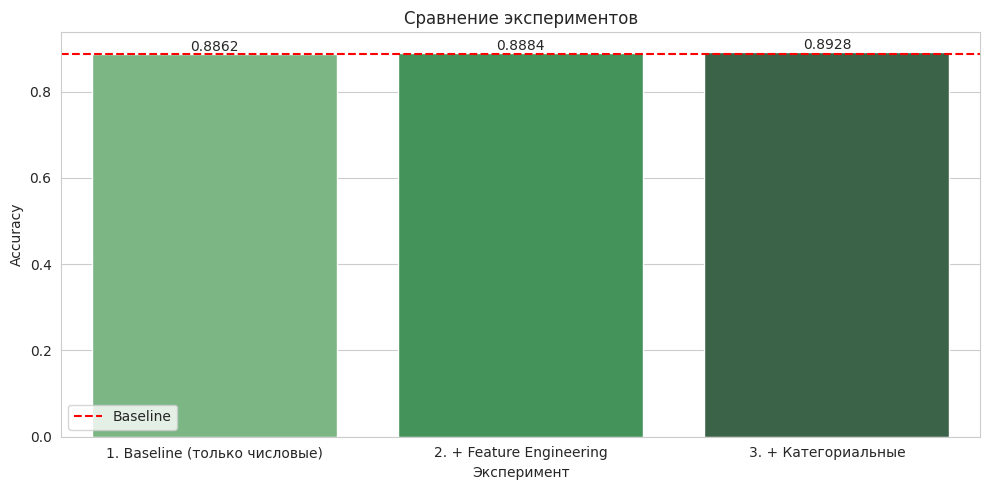

In [30]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=comparison,
    x='Эксперимент',
    y='Accuracy',
    hue='Эксперимент',
    palette='Greens_d',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f')

plt.axhline(results['baseline'], color='red', linestyle='--', label='Baseline')
plt.title('Сравнение экспериментов')
plt.legend()
plt.tight_layout()
plt.show()

### **9.3. Сформулируйте выводы**

---

> 📝 **Как отвечать на вопросы?** Дважды кликните на ячейку → впишите ответ → нажмите `Shift+Enter`

---



**Вопрос 1:** Какой accuracy показала baseline-модель?



**Ответ:** Около 0.88

**Вопрос 2:** Какие новые признаки вы создали? Помогли ли они улучшить результат?

**Ответ:** Созданы was_contacted, has_positive_balance, job_unknown, contact_unknown, is_retired, is_student, contacts_total, balance_per_age. Улучшение небольшое, но часть признаков полезна.

**Вопрос 3:** Помогло ли создание признаков из пропусков (`job_unknown` и т.д.)?


**Ответ:** Да, особенно contact_unknown. Признак отражает поведение клиента и немного улучшает модель.

**Вопрос 4:** Какая модель показала лучший результат? На сколько она лучше baseline?


**Ответ:** Лучший результат — модель со всеми категориальными признаками после One-Hot Encoding. Accuracy ≈ 0.89–0.90, что на 1–2% лучше baseline.

**Вопрос 5:** Какие гипотезы из Части 4 подтвердились, а какие нет?


>**Критерии подтверждения гипотезы**
>
>| Результат | Интерпретация |
>|-----------|---------------|
>| Accuracy выросла на **≥ 0.5%** | ✅ Гипотеза подтвердилась, признак полезен |
>| Accuracy изменилась на **< 0.5%** | ⚠️ Эффект незначительный, нужны >дополнительные тесты |
>| Accuracy **упала** | ❌ Гипотеза не подтвердилась, признак не помогает (или мешает) |



**Ответ:** Подтвердились гипотезы о важности duration, contact_unknown и категориальных признаков. Гипотеза о сильном влиянии job_unknown подтвердилась слабее.

> 💡 **Важно:** Даже если гипотеза не подтвердилась — это тоже результат! Отрицательный результат эксперимента — это знание о том, что **не** работает для данной задачи.


**Вопрос 6:** Что бы вы попробовали ещё, если бы было больше времени?


**Ответ:** Попробовал бы другие модели (Random Forest, Gradient Boosting), подбор гиперпараметров, балансировку классов и более сложные составные признаки.





---

## **Дополнительные задания (выполняются по желанию)**

1. **Исследуйте признак `duration`**: Этот признак известен только после звонка (data leakage). Попробуйте обучить модель без него — насколько упадёт accuracy?


In [ ]:
# ВАШ КОД

2. **Попробуйте использовать другие категориальные признаки**: Добавьте `month`, `poutcome` и посмотрите на результат.


In [ ]:
# ВАШ КОД

3. **Попробуйте заполнение по группам**: Заполните пропуски в `education` не общей модой, а модой внутри группы по `job`. Улучшит ли это результат?


In [ ]:
# ВАШ КОД

3. **Создайте составные признаки**: Например, `balance_per_age = balance / age` или `contacts_total = campaign + previous` и оцените их влияние на точность обученной модели.


In [ ]:
# ВАШ КОД